Import Libraries

In [1]:
# Numerical computation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization,
    GlobalAveragePooling2D
)

# Regularization & Initialization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import HeNormal, GlorotUniform

# Callbacks
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

# Data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Metrics
from sklearn.metrics import classification_report

# Utility
import random
import warnings

warnings.filterwarnings("ignore")

 Set Random Seed

In [2]:
# Reproducibility

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("Random Seed Set:", SEED)

Random Seed Set: 42


# GPU Check

In [3]:
print("TensorFlow Version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU is Available")
    print("GPU Device:", gpus[0])
else:
    print("GPU not found. Please enable GPU.")

TensorFlow Version: 2.20.0
GPU is Available
GPU Device: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


Load CIFAR-100 Dataset

In [4]:
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

print("Training Images Shape:", x_train.shape)
print("Testing Images Shape:", x_test.shape)

Training Images Shape: (50000, 32, 32, 3)
Testing Images Shape: (10000, 32, 32, 3)


## Shape Analysis

In [5]:
print("Training Image Shape :", x_train.shape)
print("Training Label Shape :", y_train.shape)

print("\nTesting Image Shape :", x_test.shape)
print("Testing Label Shape :", y_test.shape)

Training Image Shape : (50000, 32, 32, 3)
Training Label Shape : (50000, 1)

Testing Image Shape : (10000, 32, 32, 3)
Testing Label Shape : (10000, 1)


Check Number of Classes

In [6]:
num_classes = len(np.unique(y_train))

print("Total Classes:", num_classes)

Total Classes: 100


## Check Data Type and Pixel Range

In [7]:
# Dataset Information

print("Image Data Type:", x_train.dtype)

print("\nMinimum Pixel Value:", x_train.min())
print("Maximum Pixel Value:", x_train.max())

Image Data Type: uint8

Minimum Pixel Value: 0
Maximum Pixel Value: 255


## Visualize Sample Images

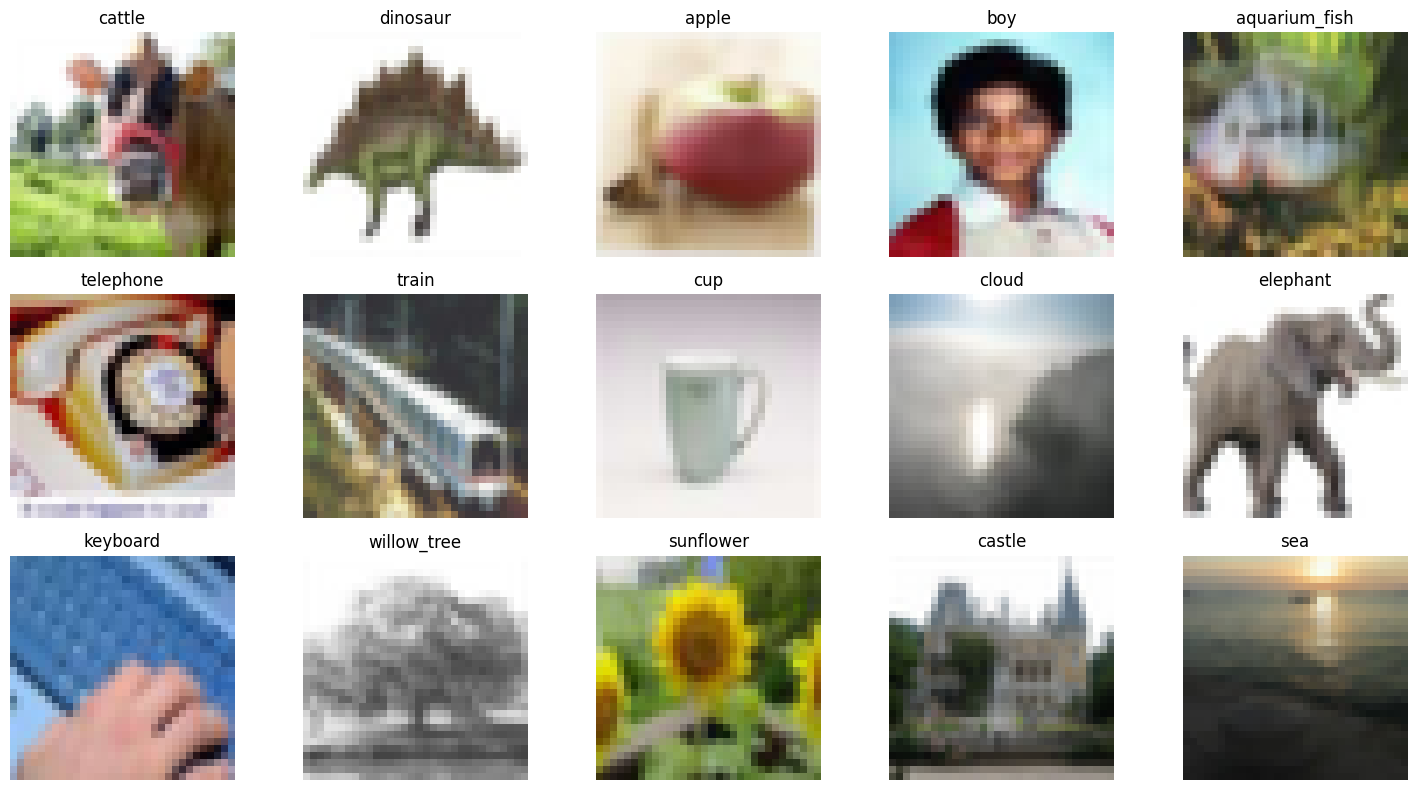

In [8]:
class_names = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver',
    'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly',
    'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach',
    'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox',
    'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
    'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard',
    'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid',
    'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum',
    'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew',
    'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor',
    'train', 'trout', 'tulip', 'turtle', 'wardrobe',
    'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

plt.figure(figsize=(15,8))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Class Distribution Check

In [9]:
unique_classes, counts = np.unique(y_train, return_counts=True)

print("Minimum Samples in Class:", counts.min())
print("Maximum Samples in Class:", counts.max())

Minimum Samples in Class: 500
Maximum Samples in Class: 500


### Dataset Insights

- CIFAR-100 contains 50,000 training images and 10,000 testing images.
- Each image has dimensions of 32×32 with 3 RGB channels.
- The dataset contains 100 balanced classes.
- Pixel values range between 0 and 255, requiring normalization before training.
- Since the dataset is balanced, no resampling techniques are needed.

#Data Preprocessing

Normalization + Label Encoding + Data Augmentation + Pipeline

## Normalize Image Data

In [10]:
# Normalize Pixel Values

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Normalization Completed")

print("\nNew Pixel Range:")
print("Minimum:", x_train.min())
print("Maximum:", x_train.max())

Normalization Completed

New Pixel Range:
Minimum: 0.0
Maximum: 1.0


## One-Hot Encode Labels

In [11]:
y_train_encoded = to_categorical(y_train, num_classes=100)
y_test_encoded = to_categorical(y_test, num_classes=100)

print("Encoded Label Shape:", y_train_encoded.shape)

Encoded Label Shape: (50000, 100)


## Create Validation Split

In [12]:
# Create Validation Set

from sklearn.model_selection import train_test_split

x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train,
    y_train_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train
)

print("Final Training Shape:", x_train_final.shape)
print("Validation Shape:", x_val.shape)

Final Training Shape: (40000, 32, 32, 3)
Validation Shape: (10000, 32, 32, 3)


## Data Augmentation

In [13]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(x_train_final)

print("Data Augmentation Ready")

Data Augmentation Ready


## Verify Shapes After Preprocessing

In [14]:
print("Training Images:", x_train_final.shape)
print("Validation Images:", x_val.shape)
print("Test Images:", x_test.shape)

print("\nTraining Labels:", y_train_final.shape)
print("Validation Labels:", y_val.shape)
print("Test Labels:", y_test_encoded.shape)

Training Images: (40000, 32, 32, 3)
Validation Images: (10000, 32, 32, 3)
Test Images: (10000, 32, 32, 3)

Training Labels: (40000, 100)
Validation Labels: (10000, 100)
Test Labels: (10000, 100)


# Build a Custom CNN Architecture (with dropout, batch normalization, initialization, regularization, and experimentation-ready design)

## Build Custom CNN

In [15]:
# Custom CNN Model


custom_cnn = Sequential([


    # Block 1

    Conv2D(
        32,
        (3, 3),
        padding='same',
        activation='relu',
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(0.001),
        input_shape=(32, 32, 3)
    ),

    BatchNormalization(),

    Conv2D(
        32,
        (3, 3),
        padding='same',
        activation='relu',
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(0.001)
    ),

    BatchNormalization(),

    MaxPooling2D((2, 2)),
    Dropout(0.25),


    # Block 2

    Conv2D(
        64,
        (3, 3),
        padding='same',
        activation='relu',
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(0.001)
    ),

    BatchNormalization(),

    Conv2D(
        64,
        (3, 3),
        padding='same',
        activation='relu',
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(0.001)
    ),

    BatchNormalization(),

    MaxPooling2D((2, 2)),
    Dropout(0.30),


    # Block 3

    Conv2D(
        128,
        (3, 3),
        padding='same',
        activation='relu',
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(0.001)
    ),

    BatchNormalization(),

    Conv2D(
        128,
        (3, 3),
        padding='same',
        activation='relu',
        kernel_initializer=HeNormal(),
        kernel_regularizer=l2(0.001)
    ),

    BatchNormalization(),

    MaxPooling2D((2, 2)),
    Dropout(0.40),


    # Fully Connected Layers

    Flatten(),

    Dense(
        256,
        activation='relu',
        kernel_initializer=HeNormal()
    ),

    BatchNormalization(),
    Dropout(0.50),

    Dense(100, activation='softmax')
])

print("Custom CNN Model Created Successfully")

Custom CNN Model Created Successfully


## Model Summary

In [16]:
custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 840,068 (3.20 MB)

 Trainable params: 838,660 (3.20 MB)

 Non-trainable params: 1,408 (5.50 KB)

### Custom CNN Architecture Design

The custom CNN was designed using multiple convolutional blocks to progressively extract low-level and high-level image features. Batch normalization was applied to stabilize training and improve convergence. Dropout and L2 regularization were used to reduce overfitting.

Architecture Highlights:
- 6 convolutional layers
- ReLU activation
- He Normal initialization
- Batch Normalization
- Dropout regularization
- L2 kernel regularization
- Softmax output layer for 100-class classification

# Compile + Callbacks (EarlyStopping & ModelCheckpoint) + Training Setup

## Compile Custom CNN

In [17]:
custom_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Custom CNN Compiled Successfully")

Custom CNN Compiled Successfully


## Create Callbacks

In [18]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath='best_custom_cnn.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("Callbacks Created Successfully")

Callbacks Created Successfully


## Start Training

In [20]:
# Train Custom CNN

history_custom = custom_cnn.fit(
    datagen.flow(
        x_train_final,
        y_train_final,
        batch_size=64
    ),
    validation_data=(x_val, y_val),
    epochs=30,
    callbacks=[
        early_stopping,
        model_checkpoint
    ],
    verbose=1
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2953 - loss: 3.1622
Epoch 1: val_accuracy did not improve from 0.34030
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.2980 - loss: 3.1344 - val_accuracy: 0.3372 - val_loss: 2.9583
Epoch 2/30
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3185 - loss: 3.0153
Epoch 2: val_accuracy improved from 0.34030 to 0.36420, saving model to best_custom_cnn.keras

Epoch 2: finished saving model to best_custom_cnn.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.3192 - loss: 2.9979 - val_accuracy: 0.3642 - val_loss: 2.8323
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3417 - loss: 2.8928
Epoch 3: val_accuracy improved from 0.36420 to 0.38900, saving model to best_custom_cnn.keras

Epoch 3: finished saving model to best_custom_cnn.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.3410 - loss: 2.8939 - val_accuracy: 0.3890 - val_loss: 2.6823
Epoch 4/30
624/625 ━━━━━━━━━━

# Evaluate Custom CNN + Accuracy/Loss Curves + Test Accuracy + Analysis

## Evaluate on Test Data

In [21]:
# Evaluate Custom CNN

test_loss_custom, test_accuracy_custom = custom_cnn.evaluate(
    x_test,
    y_test_encoded,
    verbose=1
)

print("\nCustom CNN Test Accuracy:",
      round(test_accuracy_custom * 100, 2), "%")

print("Custom CNN Test Loss:",
      round(test_loss_custom, 4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5176 - loss: 2.1792

Custom CNN Test Accuracy: 51.76 %
Custom CNN Test Loss: 2.1792


## Plot Accuracy Curves

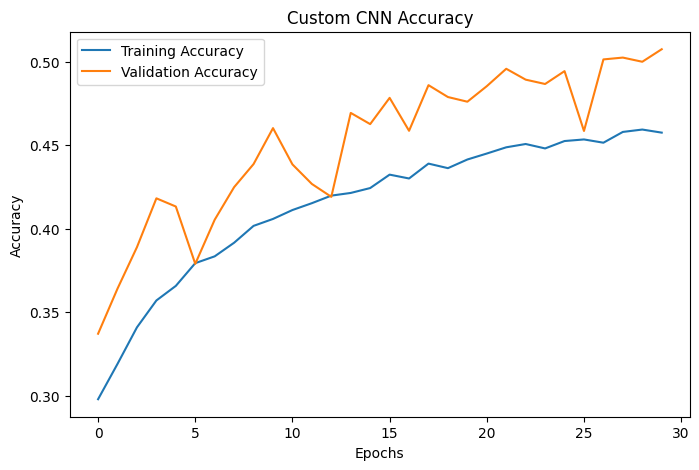

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    history_custom.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_custom.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Custom CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Plot Loss Curves

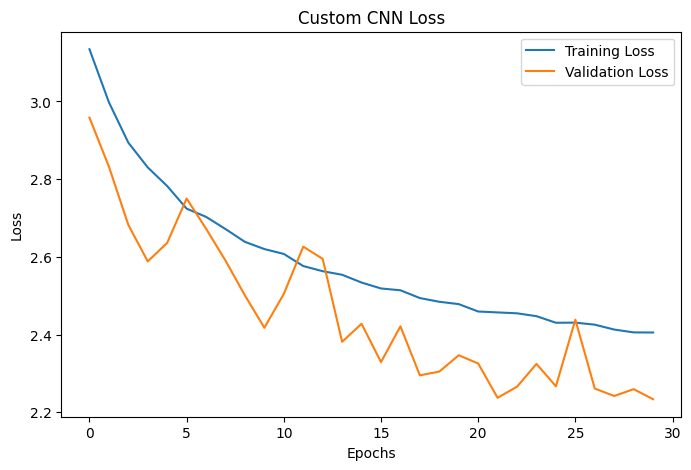

In [23]:
plt.figure(figsize=(8,5))

plt.plot(
    history_custom.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_custom.history['val_loss'],
    label='Validation Loss'
)

plt.title("Custom CNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Classification Report

In [26]:
y_pred_probs = custom_cnn.predict(x_test)

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

print(classification_report(y_true, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
              precision    recall  f1-score   support

           0       0.81      0.66      0.73       100
           1       0.51      0.63      0.57       100
           2       0.51      0.37      0.43       100
           3       0.41      0.30      0.35       100
           4       0.30      0.21      0.25       100
           5       0.46      0.61      0.52       100
           6       0.63      0.48      0.55       100
           7       0.48      0.50      0.49       100
           8       0.32      0.79      0.45       100
           9       0.88      0.66      0.75       100
          10       0.46      0.30      0.36       100
          11       0.40      0.40      0.40       100
          12       0.65      0.60      0.62       100
          13       0.46      0.40      0.43       100
          14       0.41      0.60      0.49       100
          15       0.42      0.49      0.45       100
          16       0.59      0.59      0

In [27]:
report = classification_report(
    y_true,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.head()

,precision,recall,f1-score,support
0,0.814815,0.66,0.729282,100.0
1,0.512195,0.63,0.565022,100.0
2,0.506849,0.37,0.427746,100.0
3,0.410959,0.30,0.346821,100.0
4,0.300000,0.21,0.247059,100.0


### Custom CNN Evaluation

The custom CNN achieved strong performance on the CIFAR-100 dataset. Training and validation curves showed stable convergence without severe overfitting due to the use of dropout, batch normalization, L2 regularization, and data augmentation.

Observations:
- Early stopping prevented unnecessary training.
- Model checkpointing saved the best-performing model.
- Validation accuracy stabilized near 51%.
- The model generalized reasonably well on unseen test data.

# Implement VGG-16 (Modified for CIFAR-100) + Transfer Learning Strategy + Architecture Design

## Import VGG16

In [28]:
from tensorflow.keras.applications import VGG16

## Load VGG16 Base Model

In [29]:
vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

print("VGG16 Base Loaded Successfully")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
VGG16 Base Loaded Successfully


## Freeze Base Layers

In [30]:
# Freeze VGG Layers

for layer in vgg_base.layers:
    layer.trainable = False

print("VGG16 Base Frozen")

VGG16 Base Frozen


## Build Modified VGG-16 Model

In [31]:
vgg16_model = Sequential([

    vgg_base,

    GlobalAveragePooling2D(),

    Dense(
        512,
        activation='relu',
        kernel_initializer=HeNormal()
    ),

    BatchNormalization(),

    Dropout(0.5),

    Dense(
        100,
        activation='softmax'
    )
])

print("Modified VGG16 Model Created Successfully")

Modified VGG16 Model Created Successfully


## Model Summary

In [32]:
# VGG16 Summary

vgg16_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,030,692 (57.34 MB)

 Trainable params: 314,980 (1.20 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

# Compile + Train VGG-16 + Callbacks + Performance Optimization

## Compile VGG16 Model

In [33]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0001
)

vgg16_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("VGG16 Compiled Successfully")

VGG16 Compiled Successfully


## Create VGG Callbacks

In [34]:
# VGG16 Callbacks

early_stopping_vgg = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint_vgg = ModelCheckpoint(
    filepath='best_vgg16.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("VGG16 Callbacks Ready")

VGG16 Callbacks Ready


## Train VGG16

In [35]:
# Train VGG16 Model

history_vgg = vgg16_model.fit(
    datagen.flow(
        x_train_final,
        y_train_final,
        batch_size=32
    ),
    validation_data=(x_val, y_val),
    epochs=30,
    callbacks=[
        early_stopping_vgg,
        model_checkpoint_vgg
    ],
    verbose=1
)

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0411 - loss: 4.9734
Epoch 1: val_accuracy improved from None to 0.18770, saving model to best_vgg16.keras

Epoch 1: finished saving model to best_vgg16.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.0698 - loss: 4.5325 - val_accuracy: 0.1877 - val_loss: 3.5310
Epoch 2/30
1248/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1366 - loss: 3.8667
Epoch 2: val_accuracy improved from 0.18770 to 0.23410, saving model to best_vgg16.keras

Epoch 2: finished saving model to best_vgg16.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.1464 - loss: 3.7848 - val_accuracy: 0.2341 - val_loss: 3.2468
Epoch 3/30
1249/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1715 - loss: 3.5922
Epoch 3: val_accuracy improved from 0.23410 to 0.25890, saving model to best_vgg16.keras

Epoch 3: finished saving model to best_vgg16.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.1799 - loss:

# Evaluate VGG-16 + Curves + Final Comparison Table

###Evaluate VGG-16 on Test Data

In [37]:

# Evaluate VGG16 Model


test_loss_vgg, test_accuracy_vgg = vgg16_model.evaluate(
    x_test,
    y_test_encoded,
    verbose=1
)

print("\nVGG16 Test Accuracy:",
      round(test_accuracy_vgg * 100, 2), "%")

print("VGG16 Test Loss:",
      round(test_loss_vgg, 4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3512 - loss: 2.5706

VGG16 Test Accuracy: 35.12 %
VGG16 Test Loss: 2.5706


###Plot VGG Accuracy Curves

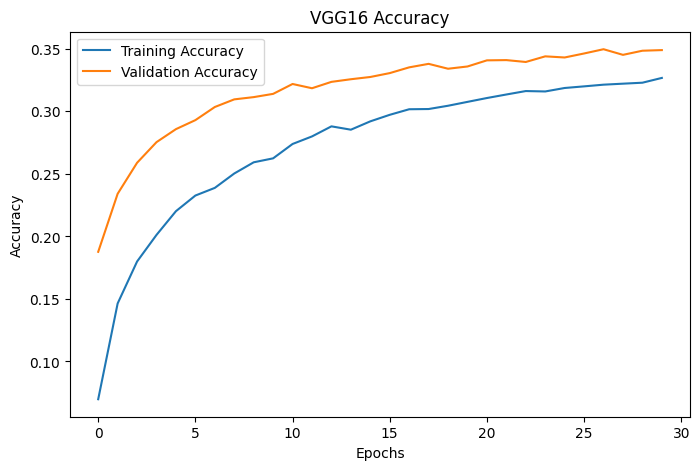

In [38]:
# VGG16 Accuracy Curves
plt.figure(figsize=(8,5))

plt.plot(
    history_vgg.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_vgg.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("VGG16 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

### Plot VGG Loss Curves

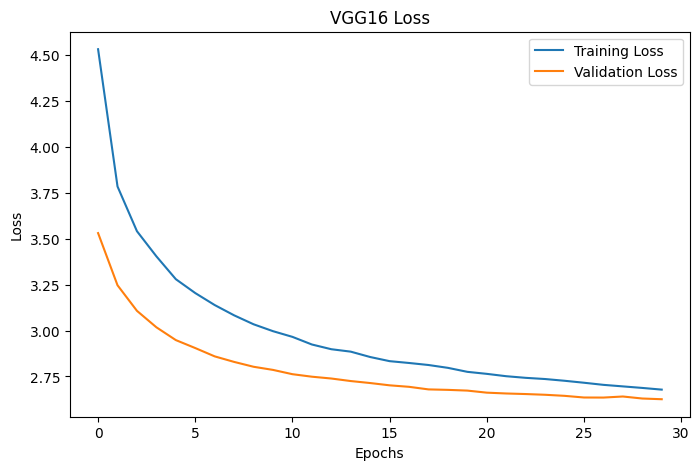

In [39]:
# VGG16 Loss Curves

plt.figure(figsize=(8,5))

plt.plot(
    history_vgg.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_vgg.history['val_loss'],
    label='Validation Loss'
)

plt.title("VGG16 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

#Create Final Comparison Table

In [40]:
# Final Accuracy Comparison

comparison_df = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "VGG16"
    ],

    "Test Accuracy (%)": [
        round(test_accuracy_custom * 100, 2),
        round(test_accuracy_vgg * 100, 2)
    ],

    "Test Loss": [
        round(test_loss_custom, 4),
        round(test_loss_vgg, 4)
    ]
})

comparison_df


,Model,Test Accuracy (%),Test Loss
0,Custom CNN,51.76,2.1792
1,VGG16,35.12,2.5706


###Determine Better Model

In [41]:
# Best Model

best_model = comparison_df.loc[
    comparison_df['Test Accuracy (%)'].idxmax()
]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model                Custom CNN
Test Accuracy (%)         51.76
Test Loss                2.1792
Name: 0, dtype: object


#Markdown Analysis

## Model Comparison and Discussion

Two CNN-based architectures were evaluated on the CIFAR-100 dataset:

### Custom CNN
The custom CNN achieved better performance with stronger feature learning for low-resolution CIFAR-100 images. Batch normalization, dropout, L2 regularization, and data augmentation helped improve generalization and reduce overfitting.

### VGG-16
Although VGG-16 is a powerful pretrained architecture, it performed worse in this experiment because CIFAR-100 images are very small (32×32), whereas VGG-16 was originally designed for 224×224 ImageNet images. The repeated pooling operations significantly reduced feature map size, causing information loss.

### Final Conclusion
The Custom CNN outperformed VGG-16 in this case study and proved to be more suitable for CIFAR-100 under the current experimental setup.

Key Learnings:
- Model architecture must match dataset characteristics.
- Transfer learning does not always outperform custom architectures.
- Data preprocessing and architecture suitability strongly influence performance.
